In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset (commonly available online)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=';')
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
wine.info()
wine.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [ ]:
X = wine.drop('quality', axis=1)
y = wine['quality']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model_gini = DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=5)
model_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [7]:
model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5)
model_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [8]:
y_pred_gini = model_gini.predict(X_test)
y_pred_entropy = model_entropy.predict(X_test)

acc_gini = accuracy_score(y_test, y_pred_gini)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print(f"Accuracy (Gini): {acc_gini:.3f}")
print(f"Accuracy (Entropy): {acc_entropy:.3f}")

Accuracy (Gini): 0.559
Accuracy (Entropy): 0.578


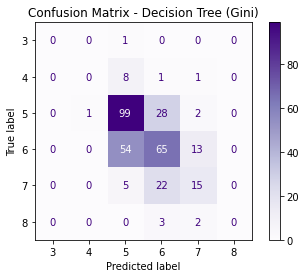

Confusion Matrix:
 [[ 0  0  1  0  0  0]
 [ 0  0  8  1  1  0]
 [ 0  1 99 28  2  0]
 [ 0  0 54 65 13  0]
 [ 0  0  5 22 15  0]
 [ 0  0  0  3  2  0]]


In [9]:
cm = confusion_matrix(y_test, y_pred_gini)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_gini.classes_)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix - Decision Tree (Gini)")
plt.show()

print("Confusion Matrix:\n", cm)

In [10]:
report = classification_report(y_test, y_pred_gini, output_dict=True)
pd.DataFrame(report).transpose()

/home/user/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/user/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/user/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,precision,recall,f1-score,support
3,0.000000,0.000000,0.000000,1.000000
4,0.000000,0.000000,0.000000,10.000000
5,0.592814,0.761538,0.666667,130.000000
6,0.546218,0.492424,0.517928,132.000000
7,0.454545,0.357143,0.400000,42.000000
8,0.000000,0.000000,0.000000,5.000000
accuracy,0.559375,0.559375,0.559375,0.559375
macro avg,0.265596,0.268518,0.264099,320.000000
weighted avg,0.525805,0.559375,0.536979,320.000000


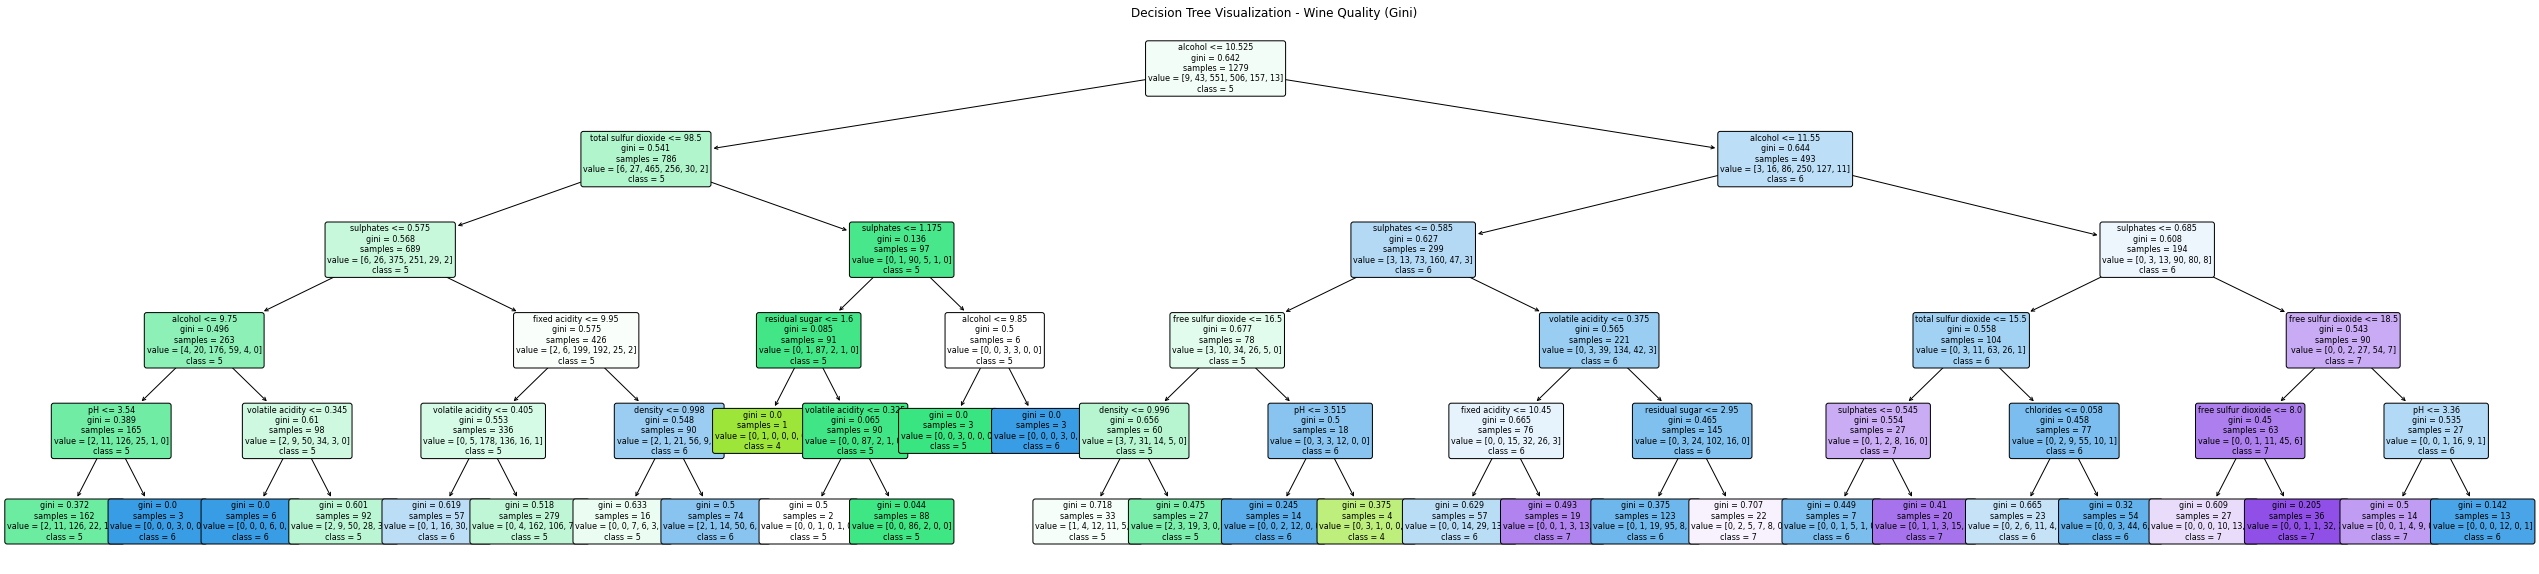

In [15]:
plt.figure(figsize=(45,10))
plot_tree(model_gini, feature_names=X.columns, class_names=[str(i) for i in sorted(y.unique())],
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Visualization - Wine Quality (Gini)")
plt.show()